### What are the most demanded skills for the top 3 most popular data roles?

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate the skill percentage
4. Plot final findings

In [62]:
# Import Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
# Filter for only United States in the job_country
df_US = df[df["job_country"] == "United States"]

In [11]:
# Explode to get individual skills
df_skills = df_US.explode("job_skills")

In [47]:
# Group skills by job_skills and job_title_short
df_skills_count = df_skills.groupby(["job_skills", "job_title_short"]).size()

# Reset index to create a dataframe
df_skills_count =df_skills_count.reset_index(name="skill_count")

# sort skill_count in descending order
df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [33]:
# Top 3 roles(Get the list of the top 3 roles)
job_titles = df_skills_count["job_title_short"].unique().tolist()   # Convert to list

job_titles = sorted(job_titles[:3]) # Sort job_titles and display top 3

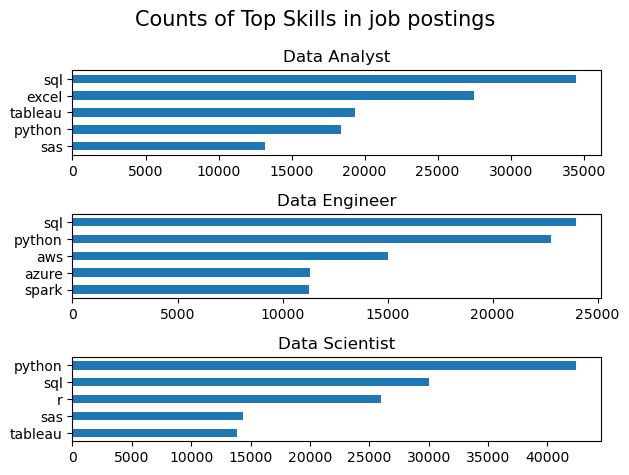

In [46]:
# Plotting the data
fig, ax = plt.subplots(len(job_titles), 1)

# Iterate through the job_titles
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count["job_title_short"] == job_title].head(5)  # Filter the job_title_short of the df_skills_count to only show job titles for the top 3 roles by the top 5 skills
    df_plot.plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)

fig.suptitle("Counts of Top Skills in job postings", fontsize=15)
plt.tight_layout()  # Fix the overlap
plt.show()

In [51]:
# Total number of jobs
df_job_title_count = df_US["job_title_short"].value_counts().reset_index(name="jobs_total")

In [50]:
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [58]:
# Merge the total jobs count(df_job_title_count) with total skills(df_skills_count)
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how="left", on="job_title_short")

df_skills_perc["skill_percent"] = 100 * (df_skills_perc["skill_count"] / df_skills_perc["jobs_total"])
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


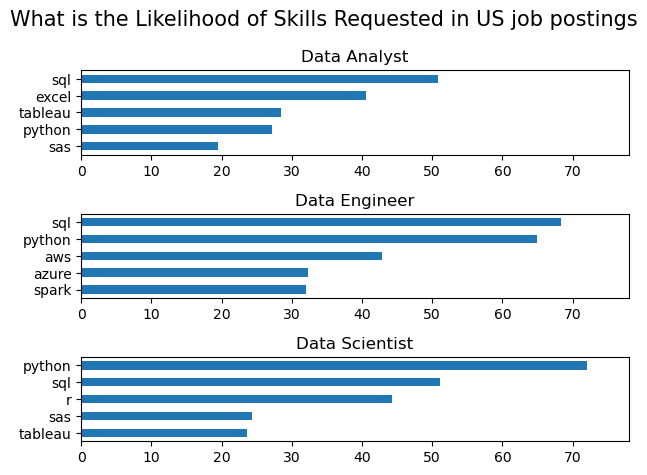

In [63]:
# Plotting the data
fig, ax = plt.subplots(len(job_titles), 1)

# Iterate through the job_titles
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc["job_title_short"] == job_title].head(5)  # Filter the job_title_short of the df_skills_count to only show job titles for the top 3 roles by the top 5 skills
    df_plot.plot(kind="barh", x="job_skills", y="skill_percent", ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 78)

fig.suptitle("What is the Likelihood of Skills Requested in US job postings", fontsize=15)
plt.tight_layout()  # Fix the overlap
plt.show()

#### Alternate solution

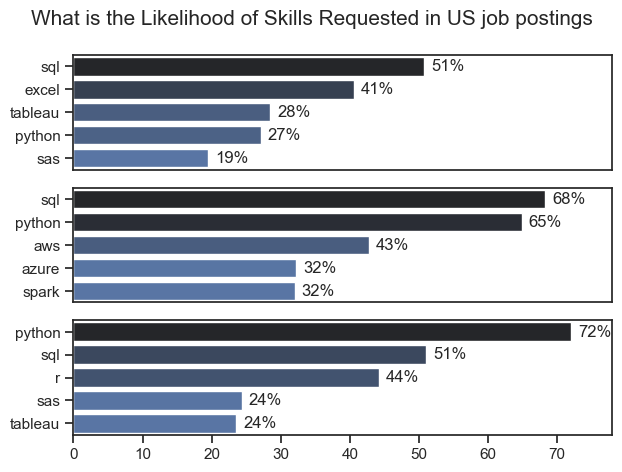

In [73]:
# Plotting the data
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style="ticks")

# Iterate through the job_titles
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc["job_title_short"] == job_title].head(5)  # Filter the job_title_short of the df_skills_count to only show job titles for the top 3 roles by the top 5 skills
    sns.barplot(data=df_plot, x="skill_percent", y="job_skills", ax=ax[i], hue="skill_percent", palette="dark:b_r")    
    ax[i].set_xlabel("")
    ax[i].set_xlim(0, 78)
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)

    # Loop through and set titles for the data using text
    for n, v in enumerate(df_plot["skill_percent"]):
        ax[i].text(v + 1, n, f"{v:.0f}%", va="center")

    # remove the x label for the top 2 charts
    if i != len(job_titles) -1:
        ax[i].set_xticks([])

fig.suptitle("What is the Likelihood of Skills Requested in US job postings", fontsize=15)
plt.tight_layout()  # Fix the overlap
plt.show()